# Primary Figure — Concordance Ladder

**Single-panel main manuscript figure.** Answers one question: when two independent
projection methods (Ensembl, CAT) are applied to the same 400+ human genome assemblies,
do they agree, and at what resolution does agreement break down?

### Design principles
1. **Strict subset funnel** — each rung conditions on the one above. The denominator
   shrinks monotonically so every percentage is directly interpretable as
   "of the features that passed the previous filter, what fraction pass this one?"
2. **Per-assembly distributions** — every rung shows the spread across all assemblies
   (dot strip with median + IQR), not just the pangenome aggregate. This makes
   both claims simultaneously: concordance is high *and* consistent.
3. **No method comparison** — this figure is about agreement, not which method is
   better. Method-specific breakdowns belong in the supplementary.

### Ladder rungs
| Rung | Question | Denominator |
|------|----------|-------------|
| 1. Gene presence | Of all loci detected by either method, what fraction found by both? | Union of gene names per assembly |
| 2. Reciprocal locus overlap | Of genes present in both, what fraction have ≥95% reciprocal body overlap? | Rung 1 passers (= RBH pairs) |
| 3. Exact transcript match | Of overlapping gene pairs, what fraction share ≥1 exactly matching transcript? | Rung 2 passers |
| 4. CDS boundary concordance | Of those with an exact transcript, what fraction have identical start+stop codons? | All rung 3 passers (non-coding genes count as failures) |
| 5. Frame integrity | Of CDS-concordant genes, what fraction have no detected frameshift? | Rung 4 passers |

### Data requirements
This notebook reads **pre-computed summary TSVs** produced by the main QC report
notebook (`hprc_annotation_qc_report.ipynb`), plus raw per-assembly pipeline outputs
where per-assembly breakdowns are needed. It does *not* reprocess GFF files.

In [8]:
import os, shutil
from pathlib import Path
import matplotlib as mpl
from matplotlib import font_manager as fm
# Use local scratch for Matplotlib cache to avoid stale NFS handles
try:
    MPLDIR = Path('/tmp') / f"{os.environ.get('USER','user')}-mplconfig"
    MPLDIR.mkdir(parents=True, exist_ok=True)
    os.environ['MPLCONFIGDIR'] = str(MPLDIR)
    # Copy bundled DejaVu fonts to local scratch and register
    import matplotlib
    ttf_src = Path(matplotlib.get_data_path())/'fonts'/'ttf'
    ttf_dst = MPLDIR/'ttf'
    shutil.copytree(ttf_src, ttf_dst, dirs_exist_ok=True)
    for f in ttf_dst.glob('*.ttf'):
        fm.fontManager.addfont(str(f))
    fm._load_fontmanager(try_read_cache=False)
    mpl.rcParams.update({'svg.fonttype':'none', 'pdf.fonttype':42, 'ps.fonttype':42,
                         'font.family':'DejaVu Sans'})
except Exception as e:
    print('Font init warning:', e)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
import warnings
import gc

warnings.filterwarnings('ignore')

# Nature-style defaults
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,      # editable text in Illustrator
    'ps.fonttype': 42,
})

print(f'pandas {pd.__version__}, numpy {np.__version__}')

pandas 3.0.1, numpy 2.4.2


## Configuration

In [9]:
# ── Paths ──────────────────────────────────────────────────────────────────
# Adjust these to point at the pipeline output directory.
OUTPUT_DIR  = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')

QC_DIR      = OUTPUT_DIR / 'qc_metrics'
RESULTS_DIR = OUTPUT_DIR / 'results'
SUMMARY_DIR = OUTPUT_DIR / 'summary_stats'
FIGURE_DIR  = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(exist_ok=True, parents=True)

CHUNK_SIZE = 50  # for chunked file reading

# ── Colour palette ─────────────────────────────────────────────────────────
GENE_COL = '#2a9d8f'
TX_COL   = '#457b9d'
CDS_COL  = '#e76f51'

print(f'Output:  {OUTPUT_DIR}')
print(f'Figures: {FIGURE_DIR}')

Output:  /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results
Figures: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/figures


In [10]:
# Parameters (public interface)
# Rung 4 denominator rule: 'monotonic' or 'coding_only'
RUNG4_DENOM = globals().get('RUNG4_DENOM', 'monotonic')
# RBH coverage threshold for rung 2
RBH_COVERAGE_THRESHOLD = float(globals().get('RBH_COVERAGE_THRESHOLD', 0.95))
# Draw thin connectors between rungs 2–5
SHOW_CONNECTORS = bool(globals().get('SHOW_CONNECTORS', True))
# Optional downsampling of per-assembly dots (int or None)
DOT_STRIP_SAMPLE = globals().get('DOT_STRIP_SAMPLE', None)


---
## 1. Compute per-assembly funnel metrics (true subset funnel)

The funnel is built by **joining gene IDs across pipeline outputs** per assembly.
Each rung explicitly filters to the passing set from the previous rung.

**Data flow:**
- Gene presence files → rung 1 (gene name matching, independent denominator)
- RBH files → rung 2 denominator is all RBH pairs; numerator is ≥95% overlap
- RBH files joined with transcript concordance files → rung 3 denominator is rung 2 passers
- Coding integrity files → rung 4 denominator is **all** rung 3 passers (non-coding genes count as failures)
- Rung 5 denominator is rung 4 passers

Rung 1 stays independent (different identifier space: gene names vs gene IDs).
Rungs 2–5 form a strict chain through the RBH gene-ID space.

### 1a. Rung 1 — Gene presence (independent denominator)

Gene presence uses **HGNC gene names**, not gene IDs, so it cannot join into
the RBH-based chain. It stays as an independent rung with its own denominator
(union of gene names per assembly).

In [11]:
# ── Shared utilities ────────────────────────────────────────────────────────

def _bool_col(series):
    """Coerce a column that may be string 'True'/'False' to boolean."""
    return series.map({'True': True, 'False': False, True: True, False: False})


def _accession_from_filename(path: Path) -> str:
    """
    Extract the assembly accession from a pipeline output filename.

    Expected patterns:
        GCA_123456789.1.gene_pairs_rbh.tsv
        GCA_123456789.1_transcript_concordance.tsv
        GCA_123456789.1_coding_integrity.tsv
        GCA_123456789.1_gene_presence.tsv

    Falls back to full stem (minus known suffixes) if pattern doesn't match.
    """
    stem = path.stem  # e.g. GCA_123456789.1.gene_pairs_rbh
    for suffix in ['.gene_pairs_rbh', '.gene_pairs_all',
                   '_transcript_concordance', '_coding_integrity',
                   '_gene_presence']:
        if stem.endswith(suffix):
            return stem[: -len(suffix)]
    return stem

print('Utilities loaded: _bool_col, _accession_from_filename')

Utilities loaded: _bool_col, _accession_from_filename


In [12]:
def compute_gene_presence_per_assembly():
    """
    For each assembly, compute:
      n_union  = number of unique gene names detected by either method
      n_both   = number detected by both
      pct_both = n_both / n_union
    """
    files = sorted(QC_DIR.rglob('*_gene_presence.tsv'))
    print(f'Found {len(files)} gene_presence files')
    if not files:
        return pd.DataFrame()

    rows = []
    for i in range(0, len(files), CHUNK_SIZE):
        chunk_files = files[i:i + CHUNK_SIZE]
        chunk_dfs = []
        for f in chunk_files:
            try:
                df = pd.read_csv(f, sep='\t')
                # Derive assembly accession from filename when column is absent
                if 'assembly_accession' not in df.columns:
                    df['assembly_accession'] = _accession_from_filename(f)
                for col in ['present_in_ensembl', 'present_in_cat']:
                    df[col] = df[col].map(
                        {'True': True, 'False': False, True: True, False: False}
                    )
                # Exclude bare ENSG stable IDs (no display name)
                df = df[~df['gene_name'].str.match(r'^ENSG', na=False)]
                chunk_dfs.append(df)
            except Exception as e:
                print(f'  error: {f.name}: {e}')

        if chunk_dfs:
            chunk = pd.concat(chunk_dfs, ignore_index=True)
            for acc, grp in chunk.groupby('assembly_accession'):
                n_union = len(grp)
                n_both = ((grp['present_in_ensembl']) & (grp['present_in_cat'])).sum()
                rows.append({
                    'assembly_accession': acc,
                    'n_union_loci': n_union,
                    'n_both_loci': int(n_both),
                    'pct_gene_presence': n_both / n_union if n_union > 0 else np.nan,
                })
            del chunk, chunk_dfs
            gc.collect()

    out = pd.DataFrame(rows)
    out.to_csv(SUMMARY_DIR / 'funnel_rung1_gene_presence_per_asm.tsv',
               sep='\t', index=False)
    print(f'  => {len(out)} assemblies')
    return out

rung1 = compute_gene_presence_per_assembly()

Found 462 gene_presence files
  => 462 assemblies


### 1b. Rungs 2–5 — True subset funnel through RBH gene-ID space

Each rung's denominator is the **previous rung's numerator** (passing set).
The chain is:

| Rung | Numerator filter | Join source |
|------|-----------------|-------------|
| 2 | `frac_ensembl_covered ≥ 0.95 AND frac_cat_covered ≥ 0.95` | RBH file |
| 3 | `n_ens_exact ≥ 1` (≥1 exact transcript structure match) | Transcript concordance file |
| 4 | `has_CDS_in_both AND start_codon_match AND stop_codon_match` | Coding integrity file |
| 5 | `NOT frameshift_detected` | Coding integrity file (same row) |

**Note:** Rung 2 uses raw coverage fractions rather than classification labels,
so both old-format (`classification`) and new-format (`classification_detailed`)
RBH files work identically.

**Denominator rule for rung 4:** The denominator is ALL rung 3 passers, not just
the protein-coding subset. Genes that passed rung 3 but are non-coding or lack
CDS in either annotation count as failures (they cannot satisfy the CDS test).
This ensures the funnel percentages decrease monotonically.

In [13]:
def compute_funnel_rungs_2_to_5():
    """
    Build the true subset funnel for rungs 2–5 by joining gene IDs
    across pipeline outputs, per assembly.

    Uses raw coverage fractions (frac_ensembl_covered, frac_cat_covered)
    for the ≥95% threshold rather than classification labels, so that
    both old-format and new-format RBH files work identically.

    Denominator rule: each rung's denominator is ALL passers from the
    previous rung.  For rung 4 (CDS boundaries), genes that passed rung 3
    but are non-coding or lack CDS in either annotation count as
    *failures*, not exclusions — this keeps the funnel strictly monotonic.

    Returns a DataFrame with one row per assembly and columns:
        n_rbh, n_r2_pass, pct_r2,
        n_r3_denom, n_r3_pass, pct_r3,
        n_r4_denom, n_r4_pass, pct_r4,
        n_r5_denom, n_r5_pass, pct_r5
    """
    # ── Locate files ──────────────────────────────────────────────────────
    rbh_files = sorted(RESULTS_DIR.rglob('*.gene_pairs_rbh.tsv'))
    tc_files  = sorted(QC_DIR.rglob('*_transcript_concordance.tsv'))
    ci_files  = sorted(QC_DIR.rglob('*_coding_integrity.tsv'))
    print(f'Files found — RBH: {len(rbh_files)}, '
          f'transcript concordance: {len(tc_files)}, '
          f'coding integrity: {len(ci_files)}')

    if not rbh_files:
        print('  ⚠ No RBH files found — cannot compute funnel.')
        return pd.DataFrame()

    # ── Load all RBH records ──────────────────────────────────────────────
    rbh_chunks = []
    for f in rbh_files:
        try:
            df = pd.read_csv(f, sep='\t')
            # Normalise column names — older files use ensembl_id/cat_id
            if 'ensembl_id' in df.columns and 'ensembl_gene_id' not in df.columns:
                df = df.rename(columns={'ensembl_id': 'ensembl_gene_id',
                                        'cat_id': 'cat_gene_id'})
            # Derive assembly accession from filename when column is absent
            if 'assembly_accession' not in df.columns:
                df['assembly_accession'] = _accession_from_filename(f)
            # Keep only columns we need (coverage fractions + IDs)
            keep = ['assembly_accession', 'ensembl_gene_id', 'cat_gene_id',
                    'frac_ensembl_covered', 'frac_cat_covered']
            keep = [c for c in keep if c in df.columns]
            rbh_chunks.append(df[keep].copy())
        except Exception as e:
            print(f'  error reading {f.name}: {e}')

    rbh_all = pd.concat(rbh_chunks, ignore_index=True)
    del rbh_chunks; gc.collect()
    print(f'  Total RBH records: {len(rbh_all):,}')

    # ── Load transcript concordance ───────────────────────────────────────
    tc_chunks = []
    for f in tc_files:
        try:
            df = pd.read_csv(f, sep='\t')
            if 'assembly_accession' not in df.columns:
                df['assembly_accession'] = _accession_from_filename(f)
            tc_chunks.append(df[['assembly_accession', 'ensembl_gene_id',
                                 'n_ens_exact']].copy())
        except Exception as e:
            print(f'  error reading {f.name}: {e}')
    tc_all = pd.concat(tc_chunks, ignore_index=True) if tc_chunks else pd.DataFrame()
    del tc_chunks; gc.collect()
    print(f'  Total transcript concordance records: {len(tc_all):,}')

    # ── Load coding integrity ─────────────────────────────────────────────
    ci_chunks = []
    for f in ci_files:
        try:
            df = pd.read_csv(f, sep='\t')
            if 'assembly_accession' not in df.columns:
                df['assembly_accession'] = _accession_from_filename(f)
            for col in ['has_ensembl_cds', 'has_cat_cds',
                        'start_codon_match', 'stop_codon_match',
                        'frameshift_detected']:
                if col in df.columns:
                    df[col] = _bool_col(df[col])
            ci_chunks.append(df[['assembly_accession', 'ensembl_gene_id',
                                 'has_ensembl_cds', 'has_cat_cds',
                                 'start_codon_match', 'stop_codon_match',
                                 'frameshift_detected']].copy())
        except Exception as e:
            print(f'  error reading {f.name}: {e}')
    ci_all = pd.concat(ci_chunks, ignore_index=True) if ci_chunks else pd.DataFrame()
    del ci_chunks; gc.collect()
    print(f'  Total coding integrity records: {len(ci_all):,}')

    # ── Per-assembly funnel ───────────────────────────────────────────────
    rows = []
    for acc, rbh_grp in rbh_all.groupby('assembly_accession'):
        # Rung 2: ≥95% reciprocal overlap (use raw fractions, not labels)
        n_rbh = len(rbh_grp)
        r2_pass_mask = (
            (rbh_grp['frac_ensembl_covered'] >= RBH_COVERAGE_THRESHOLD) &
            (rbh_grp['frac_cat_covered'] >= RBH_COVERAGE_THRESHOLD)
        )
        r2_passers = rbh_grp.loc[r2_pass_mask, ['ensembl_gene_id']].copy()
        n_r2 = len(r2_passers)

        # Rung 3: exact transcript match among rung 2 passers
        n_r3_denom = n_r2  # = rung 2 passers
        n_r3 = 0
        r3_gene_set = set()
        if not tc_all.empty and n_r2 > 0:
            tc_asm = tc_all[tc_all['assembly_accession'] == acc]
            # Inner join: only genes that passed rung 2 AND have tx data
            r3_joined = r2_passers.merge(tc_asm, on='ensembl_gene_id', how='inner')
            n_r3_denom = len(r3_joined) if len(r3_joined) > 0 else n_r2
            r3_pass_mask = r3_joined['n_ens_exact'] >= 1
            n_r3 = r3_pass_mask.sum()
            r3_gene_set = set(r3_joined.loc[r3_pass_mask, 'ensembl_gene_id'])

        # Rung 4: CDS boundary concordance (parameterised denominator)
        # Denominator options:
        #  - 'monotonic': all rung 3 passers (noncoding count as failures)
        #  - 'coding_only': only genes with CDS in both annotations
        n_r4_denom = len(r3_gene_set)
        n_r4 = 0
        r4_gene_set = set()
        if not ci_all.empty and r3_gene_set:
            ci_asm = ci_all[ci_all['assembly_accession'] == acc]
            ci_r3 = ci_asm[ci_asm['ensembl_gene_id'].isin(r3_gene_set)]
            has_both = (ci_r3['has_ensembl_cds'] == True) & (ci_r3['has_cat_cds'] == True)
            if RUNG4_DENOM == 'coding_only':
                # Denominator shrinks to coding genes only
                n_r4_denom = int(has_both.sum())
                if n_r4_denom > 0:
                    passers_mask = has_both & (ci_r3['start_codon_match'] == True) & (ci_r3['stop_codon_match'] == True)
                    n_r4 = int(passers_mask.sum())
                    r4_gene_set = set(ci_r3.loc[passers_mask, 'ensembl_gene_id'])
            else:
                # Monotonic funnel: count noncoding as failures
                has_cds = ci_r3[has_both]
                if len(has_cds) > 0:
                    passers_mask = (has_cds['start_codon_match'] == True) & (has_cds['stop_codon_match'] == True)
                    n_r4 = int(passers_mask.sum())
                    r4_gene_set = set(has_cds.loc[passers_mask, 'ensembl_gene_id'])
# Rung 5: frame integrity among ALL rung 4 passers
        # Denominator = all rung 4 passers (= r4_gene_set).
        n_r5_denom = len(r4_gene_set)
        n_r5 = 0
        if not ci_all.empty and r4_gene_set:
            ci_asm = ci_all[ci_all['assembly_accession'] == acc]
            ci_r4 = ci_asm[ci_asm['ensembl_gene_id'].isin(r4_gene_set)]
            n_r5 = (ci_r4['frameshift_detected'] == False).sum()

        rows.append({
            'assembly_accession': acc,
            'n_rbh': n_rbh,
            'n_r2_pass': n_r2,
            'pct_r2': n_r2 / n_rbh if n_rbh > 0 else np.nan,
            'n_r3_denom': n_r3_denom,
            'n_r3_pass': int(n_r3),
            'pct_r3': n_r3 / n_r3_denom if n_r3_denom > 0 else np.nan,
            'n_r4_denom': n_r4_denom,
            'n_r4_pass': int(n_r4),
            'pct_r4': n_r4 / n_r4_denom if n_r4_denom > 0 else np.nan,
            'n_r5_denom': n_r5_denom,
            'n_r5_pass': int(n_r5),
            'pct_r5': n_r5 / n_r5_denom if n_r5_denom > 0 else np.nan,
        })

    out = pd.DataFrame(rows)
    out.to_csv(SUMMARY_DIR / 'funnel_rungs2to5_per_asm.tsv',
               sep='\t', index=False)
    print(f'\n  => {len(out)} assemblies, funnel summary:')
    for c in ['pct_r2', 'pct_r3', 'pct_r4', 'pct_r5']:
        vals = out[c].dropna() * 100
        if len(vals):
            print(f'     {c}: median {vals.median():.2f}%  '
                  f'(IQR {vals.quantile(0.25):.2f}–{vals.quantile(0.75):.2f}%)')
    return out

funnel_r2r5 = compute_funnel_rungs_2_to_5()

Files found — RBH: 462, transcript concordance: 462, coding integrity: 462
  Total RBH records: 34,752,712
  Total transcript concordance records: 34,752,712
  Total coding integrity records: 8,651,534

  => 462 assemblies, funnel summary:
     pct_r2: median 97.52%  (IQR 97.37–97.71%)
     pct_r3: median 97.13%  (IQR 97.06–97.18%)
     pct_r4: median 24.57%  (IQR 24.44–24.68%)
     pct_r5: median 99.75%  (IQR 99.73–99.77%)


### 1c. Merge rung 1 with rungs 2–5 into a single per-assembly table

Rung 1 is on a different identifier space (gene names) so it merges by
`assembly_accession` only, without gene-level subsetting.

In [14]:
# Merge: rung 1 (gene presence) + rungs 2-5 (RBH-based funnel)
# Either source may be empty if files are not yet available.

if not rung1.empty:
    funnel = rung1[['assembly_accession', 'pct_gene_presence']].copy()
elif not funnel_r2r5.empty:
    # No gene-presence files; seed from RBH assemblies
    funnel = funnel_r2r5[['assembly_accession']].copy()
    funnel['pct_gene_presence'] = np.nan
    print('⚠ No gene_presence files — rung 1 will be NaN')
else:
    raise RuntimeError(
        'No pipeline output files found. Check OUTPUT_DIR / RESULTS_DIR / QC_DIR paths.'
    )

if not funnel_r2r5.empty:
    funnel = funnel.merge(
        funnel_r2r5[['assembly_accession', 'pct_r2', 'pct_r3', 'pct_r4', 'pct_r5']],
        on='assembly_accession', how='outer'
    )
else:
    for c in ['pct_r2', 'pct_r3', 'pct_r4', 'pct_r5']:
        funnel[c] = np.nan

# Rename for clarity
funnel = funnel.rename(columns={
    'pct_r2': 'pct_high_overlap',
    'pct_r3': 'pct_exact_transcript',
    'pct_r4': 'pct_cds_concordance',
    'pct_r5': 'pct_frame_integrity',
})

# Save
funnel.to_csv(SUMMARY_DIR / 'funnel_per_assembly_all_rungs.tsv',
              sep='\t', index=False)

print(f'Funnel table: {len(funnel)} assemblies × {len(funnel.columns)} columns')
print()
pct_cols = [c for c in funnel.columns if c.startswith('pct_')]
print(funnel[pct_cols].describe().T[['mean', '50%', 'min', 'max']].rename(
    columns={'50%': 'median'}
).round(4))

Funnel table: 462 assemblies × 6 columns

                        mean  median     min     max
pct_gene_presence     0.9743  0.9747  0.9476  0.9867
pct_high_overlap      0.9629  0.9752  0.0000  0.9826
pct_exact_transcript  0.9711  0.9713  0.9675  0.9737
pct_cds_concordance   0.2460  0.2457  0.2404  0.2538
pct_frame_integrity   0.9975  0.9975  0.9943  0.9984


---
## 2. Compute pangenome aggregate (for bar values)

The bar length is the **median** across assemblies (robust to outliers).
The dot strip shows the full per-assembly distribution.

In [15]:
# Ladder definition: (label, column_name, colour, level_label)
LADDER = [
    ('Gene loci detected by both methods',          'pct_gene_presence',    GENE_COL, 'Gene'),
    ('Reciprocal body overlap \u226595%',           'pct_high_overlap',     GENE_COL, 'Gene'),
    ('Share \u22651 exact transcript structure',    'pct_exact_transcript', TX_COL,   'Transcript'),
    ('Start and stop codons match',                 'pct_cds_concordance',  CDS_COL,  'CDS'),
    ('No frameshift detected',                      'pct_frame_integrity',  CDS_COL,  'CDS'),
]

# Pre-compute summary stats for annotation
ladder_stats = []
for label, col, colour, level in LADDER:
    vals = funnel[col].dropna() * 100  # convert to percent
    ladder_stats.append({
        'label': label,
        'col': col,
        'colour': colour,
        'level': level,
        'median': vals.median(),
        'mean': vals.mean(),
        'q25': vals.quantile(0.25),
        'q75': vals.quantile(0.75),
        'min': vals.min(),
        'max': vals.max(),
        'n_assemblies': len(vals),
    })

ladder_df = pd.DataFrame(ladder_stats)
print(ladder_df[['label', 'median', 'q25', 'q75', 'n_assemblies']].to_string(index=False))

                              label    median       q25       q75  n_assemblies
 Gene loci detected by both methods 97.470578 97.063299 97.848551           462
       Reciprocal body overlap ≥95% 97.515257 97.369914 97.708822           462
Share ≥1 exact transcript structure 97.131417 97.056654 97.184402           456
        Start and stop codons match 24.569173 24.440153 24.679745           456
             No frameshift detected 99.748969 99.727613 99.769932           456


---
## 3. Draw the figure

Layout: horizontal ladder bars (left panel, \u2154 width) + aligned dot-strip
distributions (right panel, \u2153 width). One row per rung.

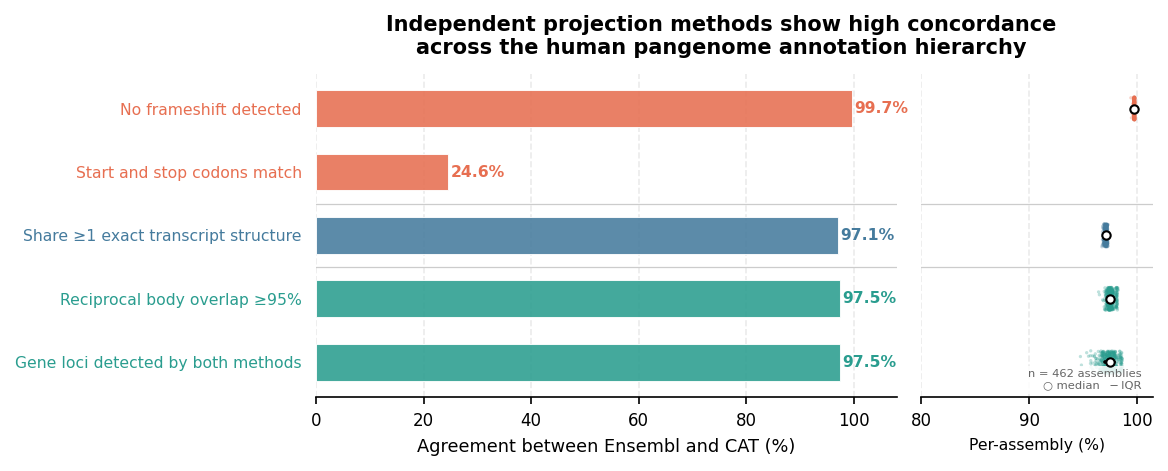

✓ Saved figure_concordance_ladder.{png,pdf}


In [16]:
n_rungs = len(LADDER)

fig = plt.figure(figsize=(7.2, 2.8))
gs  = GridSpec(1, 2, figure=fig, width_ratios=[3, 1.2], wspace=0.06)
ax_bar  = fig.add_subplot(gs[0])
ax_dot  = fig.add_subplot(gs[1], sharey=ax_bar)

y_pos = np.arange(n_rungs)

# ── Left panel: median bars ────────────────────────────────────────────────
bar_height = 0.58
for i, row in ladder_df.iterrows():
    ax_bar.barh(
        i, row['median'],
        color=row['colour'], edgecolor='white', linewidth=0.5,
        height=bar_height, alpha=0.88, zorder=2,
    )
    # Median value label — right of bar
    ax_bar.text(
        row['median'] + 0.4, i, f"{row['median']:.1f}%",
        va='center', ha='left', fontsize=7.5, fontweight='bold',
        color=row['colour'], zorder=3,
    )

# ── Coloured y-tick labels (replace brackets + legend) ─────────────────────
ax_bar.set_yticks(y_pos)
ytick_labels = ax_bar.set_yticklabels(ladder_df['label'], fontsize=7.5)
for i, row in ladder_df.iterrows():
    ytick_labels[i].set_color(row['colour'])
    ytick_labels[i].set_fontweight('medium')

# ── Thin separator lines between hierarchy levels ──────────────────────────
# Draw a subtle horizontal line where the annotation level changes
for i in range(1, n_rungs):
    if ladder_df.loc[i, 'level'] != ladder_df.loc[i - 1, 'level']:
        sep_y = i - 0.5
        ax_bar.axhline(sep_y, color='#cccccc', linewidth=0.6,
                        linestyle='-', zorder=1)
        ax_dot.axhline(sep_y, color='#cccccc', linewidth=0.6,
                        linestyle='-', zorder=1)

ax_bar.set_xlim(0, 108)
ax_bar.set_ylim(-0.55, n_rungs - 0.45)
ax_bar.set_xlabel('Agreement between Ensembl and CAT (%)', fontsize=8.5)
ax_bar.xaxis.grid(True, alpha=0.25, linestyle='--', zorder=0)
ax_bar.set_axisbelow(True)
ax_bar.spines[['top', 'right', 'left']].set_visible(False)
ax_bar.tick_params(left=False)

# ── Right panel: dot strips with zoomed x-axis ────────────────────────────
# Find the global data range for smart x-limits
all_vals = []
for _, row_meta in ladder_df.iterrows():
    v = funnel[row_meta['col']].dropna() * 100
    all_vals.append(v)
global_min = min(v.min() for v in all_vals if len(v))
# Pad 2 pp below the lowest observed point; cap at 80 to stay readable
dot_xmin = max(80, np.floor(global_min) - 2)

rng = np.random.default_rng(42)
for i, (_, row_meta) in enumerate(ladder_df.iterrows()):
    vals = funnel[row_meta['col']].dropna() * 100
    if DOT_STRIP_SAMPLE and len(vals) > DOT_STRIP_SAMPLE:
        vals = vals.sample(int(DOT_STRIP_SAMPLE), random_state=42)
    colour = row_meta['colour']

    jitter = rng.uniform(-0.18, 0.18, size=len(vals))

    ax_dot.scatter(
        vals, i + jitter,
        s=2.5, alpha=0.30, color=colour, edgecolors='none',
        rasterized=True, zorder=2,
    )

    # Median + IQR
    med = vals.median()
    q25, q75 = vals.quantile(0.25), vals.quantile(0.75)
    ax_dot.plot([q25, q75], [i, i], color='black', lw=1.8, zorder=3,
                solid_capstyle='round')
    ax_dot.plot(med, i, 'o', color='white', markersize=4,
                markeredgecolor='black', markeredgewidth=1, zorder=4)

ax_dot.set_xlim(dot_xmin, 101.5)
ax_dot.set_xlabel('Per-assembly (%)', fontsize=7.5)
ax_dot.xaxis.grid(True, alpha=0.25, linestyle='--', zorder=0)
ax_dot.set_axisbelow(True)
ax_dot.spines[['top', 'right', 'left']].set_visible(False)
ax_dot.tick_params(left=False, labelleft=False)

# Small annotation: sample size and legend for median/IQR symbols
ax_dot.text(
    0.95, 0.02,
    f'n = {int(ladder_df["n_assemblies"].max()):,} assemblies\n'
    '\u25cb median   \u2500 IQR',
    transform=ax_dot.transAxes, fontsize=5.5,
    ha='right', va='bottom', color='#666',
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=1.5),
)

# ── Title ───────────────────────────────────────────────────────────────────
fig.suptitle(
    'Independent projection methods show high concordance\n'
    'across the human pangenome annotation hierarchy',
    fontsize=10, fontweight='bold', y=1.02,
)

plt.tight_layout()

# ── Save ────────────────────────────────────────────────────────────────────
for ext in ['png', 'pdf']:
    fig.savefig(FIGURE_DIR / f'figure_concordance_ladder.{ext}',
                dpi=300, bbox_inches='tight')

plt.show()
print('\u2713 Saved figure_concordance_ladder.{png,pdf}')

In [17]:
# Optional thin connectors between rungs 2–5
if SHOW_CONNECTORS:
    for i in range(1, len(LADDER)-1):  # indices 1→3 for 5 rungs
        upper = ladder_df.loc[i, 'median']
        lower = ladder_df.loc[i+1, 'median']
        y0 = i
        y1 = i + 1
        colour = ladder_df.loc[i+1, 'colour']
        # line width scaled by pass fraction, kept subtle
        lw = 0.6 + 1.6 * (lower / upper if upper > 0 else 1.0)
        ax_bar.plot([upper*0.5, lower*0.5], [y0+0.24, y1-0.24],
                    color=colour, lw=lw, alpha=0.6, solid_capstyle='round', zorder=2)


In [18]:
# Save figure (SVG/PNG) with deterministic name encoding params
_out_tag = f"r4denom-{RUNG4_DENOM}_rbh{int(RBH_COVERAGE_THRESHOLD*100)}"
fig_name = f"figure_primary_concordance_ladder_{_out_tag}"
fig.savefig(FIGURE_DIR / f"{fig_name}.svg", bbox_inches='tight')
fig.savefig(FIGURE_DIR / f"{fig_name}.png", dpi=300, bbox_inches='tight')
print('Saved:', FIGURE_DIR / f"{fig_name}.svg")


Saved: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/figures/figure_primary_concordance_ladder_r4denom-monotonic_rbh95.svg


---
## 4. Outlier identification

Flag assemblies that are outliers (>1.5 IQR below Q1) on any rung.
These may correspond to assembly quality issues, genuinely divergent
haplotypes, or edge cases in one method's projection logic.

In [19]:
outlier_flags = pd.DataFrame({'assembly_accession': funnel['assembly_accession']})

for _, row_meta in ladder_df.iterrows():
    col = row_meta['col']
    vals = funnel[col].dropna() * 100
    q25, q75 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q75 - q25
    lower_fence = q25 - 1.5 * iqr

    outlier_flags[f'outlier_{col}'] = (funnel[col] * 100) < lower_fence

# Any assembly flagged on any rung
outlier_cols = [c for c in outlier_flags.columns if c.startswith('outlier_')]
outlier_flags['any_outlier'] = outlier_flags[outlier_cols].any(axis=1)

n_outliers = outlier_flags['any_outlier'].sum()
print(f'Assemblies flagged as outlier on \u22651 rung: {n_outliers} / {len(outlier_flags)}')

if n_outliers > 0 and n_outliers <= 20:
    flagged = funnel.loc[
        outlier_flags['any_outlier'],
        ['assembly_accession'] + [r['col'] for r in ladder_stats]
    ].copy()
    for col in [r['col'] for r in ladder_stats]:
        flagged[col] = (flagged[col] * 100).round(1)
    print(flagged.to_string(index=False))
elif n_outliers > 20:
    print(f'  (too many to list — check funnel_per_assembly_all_rungs.tsv)')

outlier_flags.to_csv(
    SUMMARY_DIR / 'funnel_outlier_flags.tsv', sep='\t', index=False
)

Assemblies flagged as outlier on ≥1 rung: 41 / 462
  (too many to list — check funnel_per_assembly_all_rungs.tsv)


---
## 5. Caption text block

Auto-generated draft caption with key numbers filled in.

In [20]:
n_asm = int(ladder_df['n_assemblies'].max())
r1_med = ladder_df.loc[0, 'median']
r5_med = ladder_df.loc[len(ladder_df) - 1, 'median']
r1_iqr = ladder_df.loc[0, 'q75'] - ladder_df.loc[0, 'q25']

caption = f"""\
**Figure X. Ensembl and CAT annotation projections converge across the human
pangenome.**  Concordance between Ensembl (linear projection) and CAT
(graph-based projection) annotations is assessed at five hierarchical levels
across {n_asm:,} HPRC assemblies.  Left: each bar shows the median percentage
of features passing that concordance test.  Rungs 2–5 form a strict subset
funnel: each rung conditions on the previous one, so denominators shrink
monotonically and every percentage is directly interpretable as "of the genes
that passed the prior filter, what fraction also pass this one?"  Rung 1 (gene
presence) uses an independent denominator (gene-name matching).  Right:
per-assembly distributions (one dot per assembly; open circle = median;
bar = interquartile range).  Gene-level agreement (top rung) is {r1_med:.1f}%
(IQR {r1_iqr:.1f} pp); even at the most stringent test — frame integrity of
CDS-concordant protein-coding genes — median agreement remains {r5_med:.1f}%.
Colours encode annotation hierarchy level: green = gene, blue = transcript,
orange = CDS.  Locus overlap uses ≥95% reciprocal gene-body coverage from
reciprocal best-hit (RBH) pairing; frameshift is inferred from CDS length
difference not divisible by 3 (3 bp tolerance on codon boundaries).
See Supplementary Figure X for per-rung breakdowns and method-specific details.
"""

print(caption)

**Figure X. Ensembl and CAT annotation projections converge across the human
pangenome.**  Concordance between Ensembl (linear projection) and CAT
(graph-based projection) annotations is assessed at five hierarchical levels
across 462 HPRC assemblies.  Left: each bar shows the median percentage
of features passing that concordance test.  Rungs 2–5 form a strict subset
funnel: each rung conditions on the previous one, so denominators shrink
monotonically and every percentage is directly interpretable as "of the genes
that passed the prior filter, what fraction also pass this one?"  Rung 1 (gene
presence) uses an independent denominator (gene-name matching).  Right:
per-assembly distributions (one dot per assembly; open circle = median;
bar = interquartile range).  Gene-level agreement (top rung) is 97.5%
(IQR 0.8 pp); even at the most stringent test — frame integrity of
CDS-concordant protein-coding genes — median agreement remains 99.7%.
Colours encode annotation hierarchy level: green

---
## Notes for revision

- **Threshold sensitivity (rung 2):** consider a supplementary showing concordance
  at 90/95/99% overlap thresholds. If robust, cite in legend; if not, discuss.
- **Frame integrity vs assembly quality:** if assembly QV scores are available,
  correlating rung 5 with QV preempts a reviewer question.
- **Denominator definitions:** rung 1 uses gene-name matching (HGNC symbols),
  while rungs 2–5 use Ensembl gene IDs from RBH pairing. Document in methods.
  Multi-mapped / one-to-many projections are handled in the supplementary figure.
- **Rung 4 denominator:** uses ALL rung 3 passers. Non-coding genes and genes
  lacking CDS in either annotation are counted as failures (they cannot pass
  the CDS boundary test). This keeps the funnel strictly monotonic.

---
## 6. Alternative layout — Option 1: Sankey / flow connectors

Same data as the main figure, but with **tapered ribbon connectors** between
adjacent rungs. The ribbon width encodes the pass fraction: the full bar width
enters the top of the connector, and only the pass fraction exits into the next
rung's denominator. Non-passing genes are shown as a faded "loss" sliver.

This makes the strict-subset relationship visually unmistakable: the reader
can literally see genes flowing down the funnel and being filtered out.

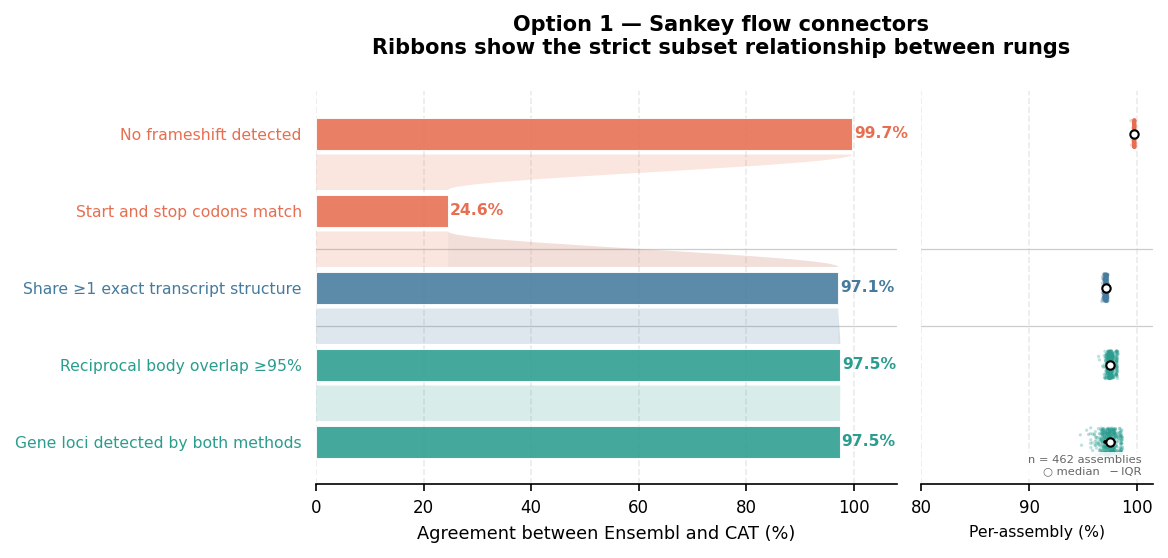

✓ Saved figure_concordance_ladder_sankey.{png,pdf}


In [21]:
"""
Option 1 — Sankey / flow-connector concordance ladder
=====================================================
Left panel : horizontal bars (same as main figure) PLUS tapered ribbon
             connectors between adjacent rungs showing the pass → next-denom
             relationship.
Right panel: dot-strip distributions (unchanged).
"""
from matplotlib.patches import FancyArrowPatch, PathPatch
from matplotlib.path import Path as MplPath
import matplotlib.colors as mcolors

n_rungs = len(LADDER)
fig = plt.figure(figsize=(7.2, 3.4))
gs  = GridSpec(1, 2, figure=fig, width_ratios=[3, 1.2], wspace=0.06)
ax_bar = fig.add_subplot(gs[0])
ax_dot = fig.add_subplot(gs[1], sharey=ax_bar)

y_pos = np.arange(n_rungs)
bar_height = 0.42          # slightly thinner to make room for ribbons
ribbon_gap = 0.06          # vertical gap between bar edge and ribbon

# ── Left panel: bars ──────────────────────────────────────────────────────
for i, row in ladder_df.iterrows():
    ax_bar.barh(
        i, row['median'],
        color=row['colour'], edgecolor='white', linewidth=0.5,
        height=bar_height, alpha=0.88, zorder=3,
    )
    ax_bar.text(
        row['median'] + 0.3, i, f"{row['median']:.1f}%",
        va='center', ha='left', fontsize=7.5, fontweight='bold',
        color=row['colour'], zorder=4,
    )

# ── Ribbons between adjacent rungs ────────────────────────────────────────
def _bezier_ribbon(ax, x_left, x_right_top, x_right_bot,
                   y_top, y_bot, colour, alpha=0.25):
    """
    Draw a smooth tapered ribbon from (x_left..x_right_top, y_top) down
    to (x_left..x_right_bot, y_bot) using cubic Bézier curves.

    The ribbon starts at the full bar width (x_right_top) and tapers to
    x_right_bot (= the next rung's median, i.e. the pass portion).
    """
    # Control-point y positions (⅓ of the way = smooth S-curve)
    y_mid1 = y_top + 0.33 * (y_bot - y_top)
    y_mid2 = y_top + 0.67 * (y_bot - y_top)

    # Right edge of ribbon: top → bottom, tapering inward
    # Left edge stays at x_left (= 0, the bar origin)
    verts = [
        # -- right edge, going downward --
        (x_right_top, y_top),          # start: right edge of upper bar
        (x_right_top, y_mid1),         # ctrl 1
        (x_right_bot, y_mid2),         # ctrl 2
        (x_right_bot, y_bot),          # end: right edge of lower bar
        # -- left edge, going back upward --
        (x_left, y_bot),               # bottom-left
        (x_left, y_mid2),              # ctrl 2
        (x_left, y_mid1),             # ctrl 1
        (x_left, y_top),              # top-left
        (x_left, y_top),              # close
    ]
    codes = [
        MplPath.MOVETO,
        MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,  # right edge
        MplPath.LINETO,                                    # bottom-left
        MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,  # left edge
        MplPath.CLOSEPOLY,
    ]
    path = MplPath(verts, codes)
    patch = PathPatch(path, facecolor=colour, edgecolor='none',
                      alpha=alpha, zorder=2)
    ax.add_patch(patch)


def _bezier_loss(ax, x_pass, x_full, y_top, y_bot, colour, alpha=0.10):
    """
    Draw a faded 'loss' sliver: the portion of the bar that doesn't pass.
    This is the right sliver from x_pass to x_full that tapers to nothing.
    """
    y_mid1 = y_top + 0.33 * (y_bot - y_top)
    y_mid2 = y_top + 0.67 * (y_bot - y_top)
    # This sliver goes from x_pass..x_full at the top and tapers to
    # x_pass..x_pass (zero width) at the bottom
    x_vanish = x_pass  # the loss disappears into the pass edge

    verts = [
        (x_full, y_top),
        (x_full, y_mid1),
        (x_vanish, y_mid2),
        (x_vanish, y_bot),
        (x_pass, y_bot),
        (x_pass, y_mid2),
        (x_pass, y_mid1),
        (x_pass, y_top),
        (x_full, y_top),
    ]
    codes = [
        MplPath.MOVETO,
        MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
        MplPath.LINETO,
        MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
        MplPath.CLOSEPOLY,
    ]
    path = MplPath(verts, codes)
    patch = PathPatch(path, facecolor=colour, edgecolor='none',
                      alpha=alpha, zorder=2)
    ax.add_patch(patch)


# Draw ribbons between rungs 1→2, 2→3, 3→4, 4→5
for i in range(n_rungs - 1):
    upper_med = ladder_df.loc[i, 'median']
    lower_med = ladder_df.loc[i + 1, 'median']
    colour    = ladder_df.loc[i + 1, 'colour']  # colour of receiving rung

    y_top = i + bar_height / 2 + ribbon_gap
    y_bot = (i + 1) - bar_height / 2 - ribbon_gap

    # Main ribbon: full bar width → next rung's bar width
    _bezier_ribbon(ax_bar, x_left=0, x_right_top=upper_med,
                   x_right_bot=lower_med, y_top=y_top, y_bot=y_bot,
                   colour=colour, alpha=0.18)

    # Loss sliver: genes that didn't pass (upper_med → lower_med)
    if upper_med > lower_med:
        _bezier_loss(ax_bar, x_pass=lower_med, x_full=upper_med,
                     y_top=y_top, y_bot=y_bot,
                     colour='#999999', alpha=0.08)

# ── Separator lines ───────────────────────────────────────────────────────
for i in range(1, n_rungs):
    if ladder_df.loc[i, 'level'] != ladder_df.loc[i - 1, 'level']:
        sep_y = i - 0.5
        ax_bar.axhline(sep_y, color='#cccccc', linewidth=0.6, zorder=1)
        ax_dot.axhline(sep_y, color='#cccccc', linewidth=0.6, zorder=1)

# ── Y labels ──────────────────────────────────────────────────────────────
ax_bar.set_yticks(y_pos)
ytick_labels = ax_bar.set_yticklabels(ladder_df['label'], fontsize=7.5)
for i, row in ladder_df.iterrows():
    ytick_labels[i].set_color(row['colour'])
    ytick_labels[i].set_fontweight('medium')

ax_bar.set_xlim(0, 108)
ax_bar.set_ylim(-0.55, n_rungs - 0.45)
ax_bar.set_xlabel('Agreement between Ensembl and CAT (%)', fontsize=8.5)
ax_bar.xaxis.grid(True, alpha=0.25, linestyle='--', zorder=0)
ax_bar.set_axisbelow(True)
ax_bar.spines[['top', 'right', 'left']].set_visible(False)
ax_bar.tick_params(left=False)

# ── Right panel: dot strips ───────────────────────────────────────────────
all_vals = []
for _, rm in ladder_df.iterrows():
    v = funnel[rm['col']].dropna() * 100
    all_vals.append(v)
global_min = min(v.min() for v in all_vals if len(v))
dot_xmin = max(80, np.floor(global_min) - 2)

rng = np.random.default_rng(42)
for i, (_, rm) in enumerate(ladder_df.iterrows()):
    vals = funnel[rm['col']].dropna() * 100
    jitter = rng.uniform(-0.18, 0.18, size=len(vals))
    ax_dot.scatter(vals, i + jitter, s=2.5, alpha=0.30,
                   color=rm['colour'], edgecolors='none',
                   rasterized=True, zorder=2)
    med = vals.median()
    q25, q75 = vals.quantile(0.25), vals.quantile(0.75)
    ax_dot.plot([q25, q75], [i, i], color='black', lw=1.8, zorder=3,
                solid_capstyle='round')
    ax_dot.plot(med, i, 'o', color='white', markersize=4,
                markeredgecolor='black', markeredgewidth=1, zorder=4)

ax_dot.set_xlim(dot_xmin, 101.5)
ax_dot.set_xlabel('Per-assembly (%)', fontsize=7.5)
ax_dot.xaxis.grid(True, alpha=0.25, linestyle='--', zorder=0)
ax_dot.set_axisbelow(True)
ax_dot.spines[['top', 'right', 'left']].set_visible(False)
ax_dot.tick_params(left=False, labelleft=False)

ax_dot.text(
    0.95, 0.02,
    f'n = {int(ladder_df["n_assemblies"].max()):,} assemblies\n'
    '\u25cb median   \u2500 IQR',
    transform=ax_dot.transAxes, fontsize=5.5,
    ha='right', va='bottom', color='#666',
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=1.5),
)

fig.suptitle(
    'Option 1 — Sankey flow connectors\n'
    'Ribbons show the strict subset relationship between rungs',
    fontsize=10, fontweight='bold', y=1.03,
)

plt.tight_layout()
for ext in ['png', 'pdf']:
    fig.savefig(FIGURE_DIR / f'figure_concordance_ladder_sankey.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('\u2713 Saved figure_concordance_ladder_sankey.{png,pdf}')

---
## 7. Alternative layout — Option 4: Thin connecting lines with pass/fail split

Same data, lighter visual treatment. Between adjacent rungs a thin vertical
connector line splits into two branches:
- **Pass** (solid, coloured): continues down to the next rung, thickness
  proportional to the pass fraction.
- **Fail** (dashed, grey): peels off to the right and fades, showing the
  fraction that was lost at this step.

A small "−X.X pp" annotation labels each loss branch so the reader can
quantify the drop without mental arithmetic.

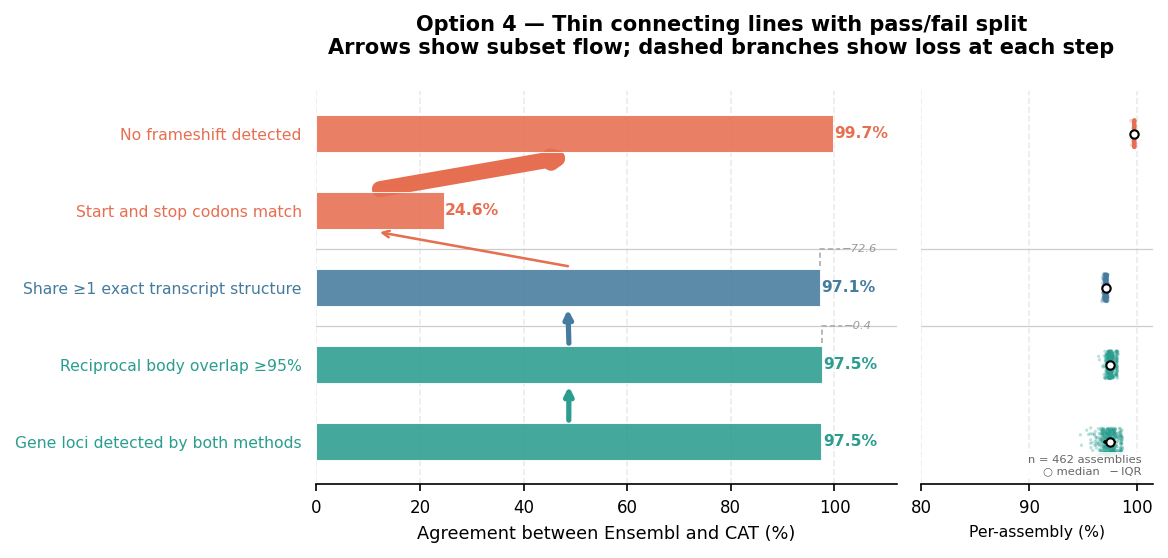

✓ Saved figure_concordance_ladder_connectors.{png,pdf}


In [22]:
"""
Option 4 — Thin connecting lines with pass/fail split
=====================================================
Left panel : horizontal bars with thin connector lines between rungs.
             A solid coloured line shows the "pass" flow; a dashed grey
             branch peels off to show the "loss" at each step.
Right panel: dot-strip distributions (unchanged).
"""
from matplotlib.patches import FancyArrowPatch

n_rungs = len(LADDER)
fig = plt.figure(figsize=(7.2, 3.4))
gs  = GridSpec(1, 2, figure=fig, width_ratios=[3, 1.2], wspace=0.06)
ax_bar = fig.add_subplot(gs[0])
ax_dot = fig.add_subplot(gs[1], sharey=ax_bar)

y_pos = np.arange(n_rungs)
bar_height = 0.48

# ── Left panel: bars ──────────────────────────────────────────────────────
for i, row in ladder_df.iterrows():
    ax_bar.barh(
        i, row['median'],
        color=row['colour'], edgecolor='white', linewidth=0.5,
        height=bar_height, alpha=0.88, zorder=3,
    )
    ax_bar.text(
        row['median'] + 0.3, i, f"{row['median']:.1f}%",
        va='center', ha='left', fontsize=7.5, fontweight='bold',
        color=row['colour'], zorder=4,
    )

# ── Connecting lines between adjacent rungs ───────────────────────────────
connector_gap = 0.04  # gap between bar edge and connector start

for i in range(n_rungs - 1):
    upper_med = ladder_df.loc[i, 'median']
    lower_med = ladder_df.loc[i + 1, 'median']
    loss_pp   = upper_med - lower_med
    colour    = ladder_df.loc[i + 1, 'colour']

    y_start = i + bar_height / 2 + connector_gap
    y_end   = (i + 1) - bar_height / 2 - connector_gap
    y_mid   = (y_start + y_end) / 2

    # ── Pass line: solid, coloured, from bar midpoint → next bar midpoint
    # Width proportional to the pass fraction (scale: 0.8–2.5 pt)
    pass_frac = lower_med / upper_med if upper_med > 0 else 1.0
    pass_lw = 0.8 + 1.7 * pass_frac  # thicker = more pass

    # Vertical connector on the left side of the bar (at x = upper_med/2)
    x_pass = lower_med / 2  # midpoint of the lower (narrower) bar

    ax_bar.annotate(
        '', xy=(x_pass, y_end), xytext=(upper_med / 2, y_start),
        arrowprops=dict(
            arrowstyle='->', color=colour, lw=pass_lw,
            connectionstyle='arc3,rad=0',
            mutation_scale=8,
            shrinkA=0, shrinkB=0,
        ),
        zorder=2,
    )

    # ── Loss branch: dashed grey, peels off to the right
    if loss_pp > 0.05:  # only draw if there's a visible loss
        # Start from the right edge of the upper bar, go to the right
        x_loss_start = upper_med  # right edge of upper bar
        x_loss_end   = upper_med + 4  # extends a bit to the right

        # Draw the loss branch as two segments:
        # 1. Vertical drop from bar edge to midpoint
        # 2. Horizontal peel-off to the right
        ax_bar.plot(
            [x_loss_start, x_loss_start, x_loss_end],
            [y_start, y_mid, y_mid],
            color='#aaaaaa', linewidth=0.8, linestyle=(0, (3, 2)),
            solid_capstyle='round', zorder=2,
        )

        # Small "loss" label
        ax_bar.text(
            x_loss_end + 0.3, y_mid,
            f'\u2212{loss_pp:.1f}',
            fontsize=5.5, color='#999999', va='center', ha='left',
            fontstyle='italic', zorder=4,
        )

# ── Separator lines ───────────────────────────────────────────────────────
for i in range(1, n_rungs):
    if ladder_df.loc[i, 'level'] != ladder_df.loc[i - 1, 'level']:
        sep_y = i - 0.5
        ax_bar.axhline(sep_y, color='#cccccc', linewidth=0.6, zorder=1)
        ax_dot.axhline(sep_y, color='#cccccc', linewidth=0.6, zorder=1)

# ── Y labels ──────────────────────────────────────────────────────────────
ax_bar.set_yticks(y_pos)
ytick_labels = ax_bar.set_yticklabels(ladder_df['label'], fontsize=7.5)
for i, row in ladder_df.iterrows():
    ytick_labels[i].set_color(row['colour'])
    ytick_labels[i].set_fontweight('medium')

ax_bar.set_xlim(0, 112)   # slightly wider to fit loss labels
ax_bar.set_ylim(-0.55, n_rungs - 0.45)
ax_bar.set_xlabel('Agreement between Ensembl and CAT (%)', fontsize=8.5)
ax_bar.xaxis.grid(True, alpha=0.25, linestyle='--', zorder=0)
ax_bar.set_axisbelow(True)
ax_bar.spines[['top', 'right', 'left']].set_visible(False)
ax_bar.tick_params(left=False)

# ── Right panel: dot strips ───────────────────────────────────────────────
all_vals = []
for _, rm in ladder_df.iterrows():
    v = funnel[rm['col']].dropna() * 100
    all_vals.append(v)
global_min = min(v.min() for v in all_vals if len(v))
dot_xmin = max(80, np.floor(global_min) - 2)

rng = np.random.default_rng(42)
for i, (_, rm) in enumerate(ladder_df.iterrows()):
    vals = funnel[rm['col']].dropna() * 100
    jitter = rng.uniform(-0.18, 0.18, size=len(vals))
    ax_dot.scatter(vals, i + jitter, s=2.5, alpha=0.30,
                   color=rm['colour'], edgecolors='none',
                   rasterized=True, zorder=2)
    med = vals.median()
    q25, q75 = vals.quantile(0.25), vals.quantile(0.75)
    ax_dot.plot([q25, q75], [i, i], color='black', lw=1.8, zorder=3,
                solid_capstyle='round')
    ax_dot.plot(med, i, 'o', color='white', markersize=4,
                markeredgecolor='black', markeredgewidth=1, zorder=4)

ax_dot.set_xlim(dot_xmin, 101.5)
ax_dot.set_xlabel('Per-assembly (%)', fontsize=7.5)
ax_dot.xaxis.grid(True, alpha=0.25, linestyle='--', zorder=0)
ax_dot.set_axisbelow(True)
ax_dot.spines[['top', 'right', 'left']].set_visible(False)
ax_dot.tick_params(left=False, labelleft=False)

ax_dot.text(
    0.95, 0.02,
    f'n = {int(ladder_df["n_assemblies"].max()):,} assemblies\n'
    '\u25cb median   \u2500 IQR',
    transform=ax_dot.transAxes, fontsize=5.5,
    ha='right', va='bottom', color='#666',
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=1.5),
)

fig.suptitle(
    'Option 4 — Thin connecting lines with pass/fail split\n'
    'Arrows show subset flow; dashed branches show loss at each step',
    fontsize=10, fontweight='bold', y=1.03,
)

plt.tight_layout()
for ext in ['png', 'pdf']:
    fig.savefig(FIGURE_DIR / f'figure_concordance_ladder_connectors.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('\u2713 Saved figure_concordance_ladder_connectors.{png,pdf}')